## Auto loan prediction

In [41]:
# load relevant libraries
library(tidyverse)  # data wrangling, includes dplyr
library(caret)  # model wrapper package
library(glmnet) # elastic net regression 
library(ggplot2)  # plots
library(forcats) # plots
library(e1071)  # needed for cross-validation elastic net implementation
library(ROCR)  # used to get performance metrics for charts
library(MLmetrics)  # used to optimize tuning for random forest for F1-Score


In [42]:
data_dictionary = read.csv("data/Data_Dictionary.csv")

# Display the data dictionary for reference
data_dictionary

Variable,Description
<chr>,<chr>
ID,Client Loan application ID
Client_Income,Client Income in $
Car_Owned,Any Car owned by client before applying for the loan for another car (0 means No and 1 means otherwise)
Bike_Owned,Any bike owned by client (0 means No and 1 means otherwise)
Active_Loan,Any other active loan at the time of aplication of loan (0 means No and 1 means otherwise)
House_Own,Any house owned by client (0 means No and 1 means otherwise)
Child_Count,Number of children the client has
Credit_Amount,Credit amount of the loan in $
Loan_Annuity,Loan annuity in $


In [43]:
data = read.csv("data/Train_Dataset.csv")

# Convert the following to numeric
to_num = c('Client_Income', 'Credit_Amount', 'Loan_Annuity', 'Population_Region_Relative', 'Age_Days', 'Employed_Days', 
           'Registration_Days', 'ID_Days', 'Mobile_Tag', 'Score_Source_3') 

data[, to_num] = suppressWarnings(lapply(data[, to_num],as.numeric))
# Client_Occupation set blank to None, leave NA


to_factor = c('Application_Process_Hour', 'Application_Process_Day', 'Accompany_Client', 'Client_Income_Type',
             'Client_Education', 'Client_Marital_Status', 'Client_Gender', 'Loan_Contract_Type', 
              'Client_Housing_Type','Client_Occupation', 'Client_Permanent_Match_Tag', 'Client_Contact_Work_Tag', 
              'Type_Organization')

data[, to_factor] = lapply(data[, to_factor],as.factor)

#Own house age to 0, Own_House will indicate if missing.

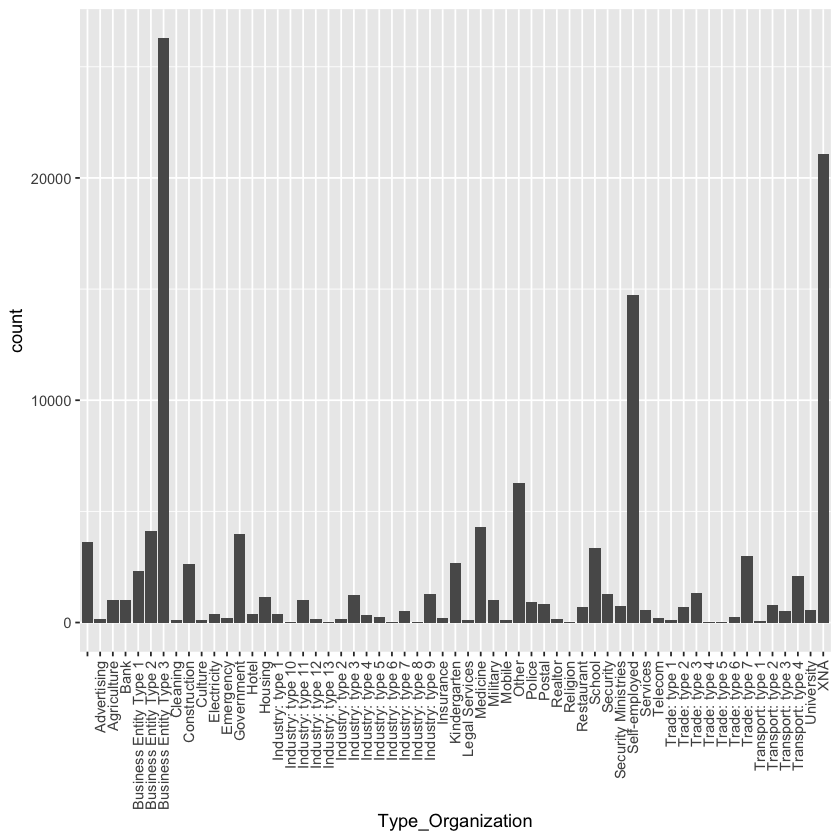

In [44]:
# Distribution of the 59 levels of the Type_Organization factor - Training Data
ggplot(data) +
geom_bar(aes(x=Type_Organization)) +
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))


In [45]:
# Perform LASSO to identify categories to merge for Type Organization 

x_train <- model.matrix( ~ Type_Organization, data = data)
lasso_type_org = glmnet(x_train, data$Default, family = "binomial", alpha=1)

print(coef(lasso_type_org)[,20][which(abs(coef(lasso_type_org)[,20]) > 0.1)])



                         (Intercept)         Type_OrganizationAgriculture 
                          -2.4326990                            0.1687661 
               Type_OrganizationBank        Type_OrganizationConstruction 
                          -0.1098251                            0.3364007 
          Type_OrganizationInsurance              Type_OrganizationPolice 
                          -0.1514028                           -0.2290746 
             Type_OrganizationSchool            Type_OrganizationSecurity 
                          -0.2566446                            0.1275355 
Type_OrganizationSecurity Ministries       Type_OrganizationSelf-employed 
                          -0.1755129                            0.1933645 
  Type_OrganizationTransport: type 3                 Type_OrganizationXNA 
                           0.4115849                           -0.3215006 


In [46]:
# Type_Organization variables with largest non-zero coefficients

vars_to_keep = c('XNA'
,'Bank'
,'Insurance'
,'School'
,'Security Ministries'
,'Transport: type 3'
,'Agriculture'
,'Construction'
,'Police'
,'Security'
,'Self-employed')

data = data %>%
    mutate(Type_Organization = case_when(as.character(Type_Organization) %in% vars_to_keep ~ as.character(Type_Organization), TRUE ~ "Other") %>% as.factor())


# set reference level to "Other"
data[, 'Type_Organization'] = relevel(data[, 'Type_Organization'], ref = 'Other')
levels(data[, 'Type_Organization'])

[1] "Other"               "Agriculture"         "Bank"               
 [4] "Construction"        "Insurance"           "Police"             
 [7] "School"              "Security"            "Security Ministries"
[10] "Self-employed"       "Transport: type 3"   "XNA"

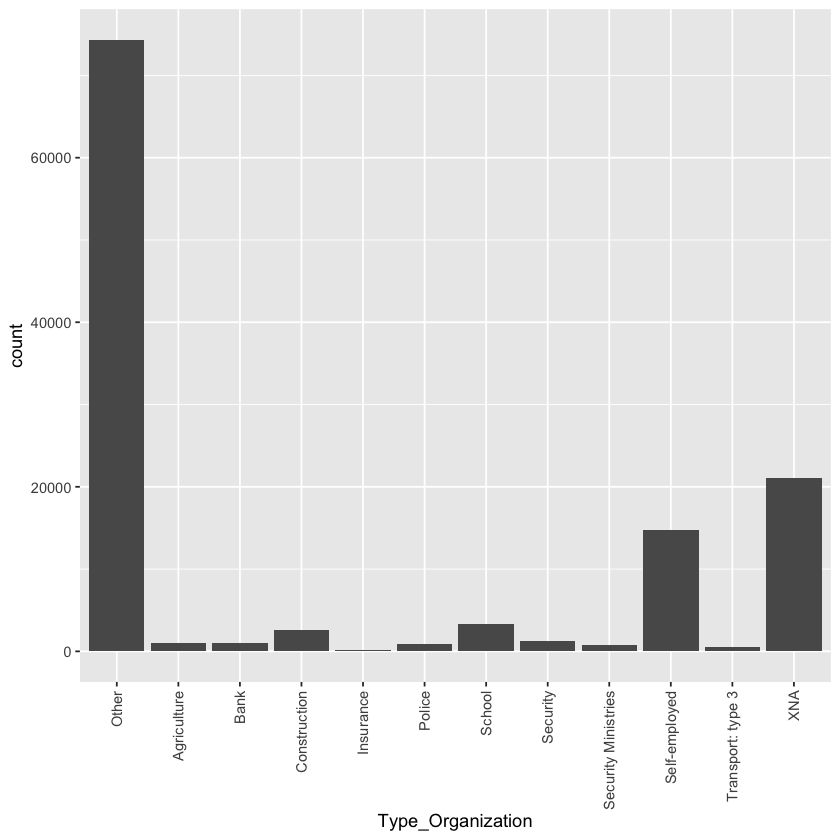

In [47]:
# Distribution of the levels after LASSO
ggplot(data) +
geom_bar(aes(x=Type_Organization)) +
theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))



In [48]:
x_train <- model.matrix( ~ Client_Occupation, data = data)
lasso_client_occ = glmnet(x_train, data$Default, family = "binomial", alpha=1)

# lasso_client_occ
print(coef(lasso_client_occ)[,20][which(abs(coef(lasso_client_occ)[,20]) > 0.1)])

                        (Intercept)        Client_OccupationAccountants 
                         -2.5757229                          -0.1022047 
          Client_OccupationCleaning            Client_OccupationCooking 
                          0.1137728                           0.3599217 
           Client_OccupationDrivers           Client_OccupationLaborers 
                          0.4119356                           0.3843504 
Client_OccupationLow-skill Laborers              Client_OccupationSales 
                          0.8294368                           0.2870227 
          Client_OccupationSecurity 
                          0.3847612 


In [49]:
# Client_Occupation variables with largeset non-zero coefficient

vars_to_keep = c('Drivers', 'Low-skill Laborers', 'Security', 'Sales', 'Laborers', 'Cooking', 
                 'Cleaning', 'Accountants') 

# re-factor Client_Occupation
data = data %>%
    mutate(Client_Occupation = case_when(as.character(Client_Occupation) %in% vars_to_keep ~ as.character(Client_Occupation), TRUE ~ "Other") %>% as.factor())

# check to make sure there are 9 levels
# str(data[, 'Client_Occupation'])

# set reference level to "Other"
data[, 'Client_Occupation'] = relevel(data[, 'Client_Occupation'], ref = 'Other')
levels(data[, 'Client_Occupation'])

[1] "Other"              "Accountants"        "Cleaning"          
[4] "Cooking"            "Drivers"            "Laborers"          
[7] "Low-skill Laborers" "Sales"              "Security"

In [50]:
# Perform LASSO to identify categories to merge for Application_Process_Hour
x_train <- model.matrix( ~ Application_Process_Hour, data = data)
lasso_app_hour = glmnet(x_train, data$Default, family = "binomial", alpha=1)

# print(coef(lasso_app_hour)[,20][which(abs(coef(lasso_app_hour)[,20]) > 0.1)])


In [51]:
# set values from our LASSO regression
vars_to_keep = c('1', '19', '6', '0', '17', '5', '7') 

# re-factor Application_Process_Hour
data = data %>%
    mutate(Application_Process_Hour = case_when(as.character(Application_Process_Hour) %in% vars_to_keep ~ as.character(Application_Process_Hour), TRUE ~ "Other") %>% as.factor())

# set reference level to "Other"
data[, 'Application_Process_Hour'] = relevel(data[, 'Application_Process_Hour'], ref = 'Other')

In [52]:
# check for columns with missing values
cols_with_missing = which(colSums(is.na(data)) > 0 )

# create dummy flags for columns with missing data
missing_data = ifelse(is.na(data[,cols_with_missing]),1,0)

# change column names
colnames(missing_data)<-paste(colnames(missing_data),"na",sep="_")

# append to data frame
data = cbind(data, missing_data)

# check to make sure we added correctly
# str(data)

In [53]:
# fix some values in the Accompany_Client data
vals_to_fix = c("", "##",  NA_character_, "0")
data = data %>% 
    mutate(Accompany_Client = case_when(as.character(Accompany_Client) %in% vals_to_fix ~ "Nothing", TRUE ~ as.character(Accompany_Client)) %>% as.factor(),
          Application_Process_Day = case_when(as.character(Application_Process_Day) %in% vals_to_fix ~ "0", TRUE ~ as.character(Application_Process_Day)) %>% as.factor())

# set reference level to "Nothing" or "0" 
data[, 'Accompany_Client'] = relevel(data[, 'Accompany_Client'], ref = 'Nothing')
data[, 'Application_Process_Day'] = relevel(data[, 'Application_Process_Day'], ref = '0')

# remove these non-numeric columns
drop = c('Accompany_Client', 'Application_Process_Day')
cols_with_missing = cols_with_missing[!(names(cols_with_missing) %in% drop)]

# replace missing values in non-numeric columns
data[,cols_with_missing] = data[,cols_with_missing] %>% mutate_all(~replace_na(.,0))

In [54]:
# Ensure there is no more missing data 
print(which(colSums(is.na(data)) > 0 )) 
# str(data)
# names(data)[!(names(data) %in% names(testDf))]  # checking for missing column

named integer(0)


In [55]:
# set random seed
set.seed(1990)

# create training/test split (80/20)
trainIndex <- caret::createDataPartition(data$Default, p = .8, 
                                  list = FALSE, 
                                  times = 1)


# drop ID column and split data
training = data[trainIndex, !(names(data) %in% c("ID"))]
test = data[-trainIndex, !(names(data) %in% c("ID"))]

# create random subsample for random forest and svm
training_10pct = training[sample(nrow(training), round(nrow(training)*.10, 0)), ]

# fix labels with spaces in 
training_10pct = training_10pct %>% 
  mutate(Client_Income_Type = factor(Client_Income_Type, labels = make.names(unique(Client_Income_Type))), 
         Client_Occupation = factor(Client_Occupation, labels = make.names(levels(Client_Occupation))), 
        Client_Education = factor(Client_Education, labels = make.names(levels(Client_Education))), 
        Client_Marital_Status = factor(Client_Marital_Status, labels = make.names(levels(Client_Marital_Status))), 
        Type_Organization = factor(Type_Organization, labels = make.names(levels(Type_Organization))), 
        Client_Gender = factor(Client_Gender, labels = make.names(unique(Client_Gender))), 
        Loan_Contract_Type = factor(Loan_Contract_Type, labels = make.names(levels(Loan_Contract_Type))), 
        Client_Housing_Type = factor(Client_Housing_Type, labels = make.names(levels(Client_Housing_Type))),
        Application_Process_Day = factor(Client_Housing_Type, labels = make.names(levels(Application_Process_Day))))


# ensure Default prevalence is consistent
summary(training$Default)
summary(test$Default)
summary(training_10pct$Default)

#Default rate is ~8% in all three samples, as expected

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.08088 0.00000 1.00000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.08042 0.00000 1.00000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.07971 0.00000 1.00000 

## MODELS START BELOW THIS CELL

In [150]:
# force test data to same levels as truncated training sample 
defaultW <- getOption("warn") # using to clean up output
options(warn = -1)

test_test = test %>%
    mutate(Client_Income_Type = 
           factor(case_when(!as.character(Client_Income_Type) %in% levels(training_10pct$Client_Income_Type) ~ "X"
                     , TRUE~ as.character(Client_Income_Type) ), levels = levels(training_10pct$Client_Income_Type))
           , Client_Gender = 
           factor(case_when(!as.character(Client_Gender) %in% levels(training_10pct$Client_Gender) ~ "X"
                     , TRUE~ as.character(Client_Gender) ), levels = levels(training_10pct$Client_Gender))
           ,Client_Education = 
           factor(case_when(!as.character(Client_Education) %in% levels(training_10pct$Client_Education) ~ "X"
                     , TRUE~ as.character(Client_Education) ), levels = levels(training_10pct$Client_Education))
           ,Client_Marital_Status = 
           factor(case_when(!as.character(Client_Marital_Status) %in% levels(training_10pct$Client_Marital_Status) ~ "X"
                     , TRUE~ as.character(Client_Marital_Status) ), levels = levels(training_10pct$Client_Marital_Status))
          )
# levels(test_test$Client_Gender)
# levels(test$Client_Gender)
# levels(training_10pct$Client_Gender)

# print(which(colSums(is.na(test_test)) > 0 )) 

test_test = test_test %>% 
  mutate(Client_Income_Type = factor(Client_Income_Type, labels = make.names(unique(Client_Income_Type))), 
         Client_Occupation = factor(Client_Occupation, labels = make.names(levels(Client_Occupation))), 
        Client_Education = factor(Client_Education, labels = make.names(unique(Client_Education))), 
        Client_Marital_Status = factor(Client_Marital_Status, labels = make.names(levels(Client_Marital_Status))), 
        Type_Organization = factor(Type_Organization, labels = make.names(levels(Type_Organization))), 
        Client_Gender = factor(Client_Gender, labels = make.names(levels(Client_Gender))), 
        Loan_Contract_Type = factor(Loan_Contract_Type, labels = make.names(levels(Loan_Contract_Type))), 
        Client_Housing_Type = factor(Client_Housing_Type, labels = make.names(levels(Client_Housing_Type))),
        Application_Process_Day = factor(Client_Housing_Type, labels = make.names(levels(Application_Process_Day))))


[1] "Male"   "Female" "X"

[1] ""       "Female" "Male"   "XNA"

[1] "Male"   "Female" "X"

In [ ]:

# store full default vector
actual = factor(training$Default, levels=c(0,1))

logit_train = training %>% 
    mutate(Client_Income = (Client_Income - mean(training$Client_Income)) / sd(training$Client_Income)
           , Credit_Amount = (Credit_Amount - mean(training$Credit_Amount)) / sd(training$Credit_Amount)
           , Employed_Days = (Employed_Days - mean(training$Employed_Days)) / sd(training$Employed_Days)
           , Loan_Annuity = (Loan_Annuity - mean(training$Loan_Annuity)) / sd(training$Loan_Annuity))

# define training control
train_control <- trainControl(method = "cv", number = 5)

# train the model on training set
logit <- train(factor(Default, levels=c(0,1)) ~ .,
               data = logit_train,
               trControl = train_control,
               method = "glm",
               family=binomial())


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from a rank-deficient fit may be misleading”


,estimates,significance,absEst
,<dbl>,<dbl>,<dbl>
Score_Source_3,-2.867,0.000,2.8672002
Client_Income_TypeUnemployed,2.738,0.005,2.7381596
Score_Source_2,-1.515,0.000,1.5151038
Score_Source_3_na,-1.466,0.000,1.4658530
Application_Process_Hour0,1.445,0.007,1.4446234
Score_Source_1,-1.322,0.000,1.3216866
Score_Source_2_na,-0.669,0.000,0.6692204
Social_Circle_Default,-0.653,0.001,0.6528047
Type_OrganizationPolice,-0.522,0.005,0.5224098


Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from a rank-deficient fit may be misleading”
Warning message:
“Removed 1 row(s) containing missing values (geom_path).”
Warning message:
“Removed 1 row(s) containing missing values (geom_path).”
Warning message in predict.lm(object, newdata, se.fit, scale = 1, type = if (type == :
“prediction from a rank-deficient fit may be misleading”


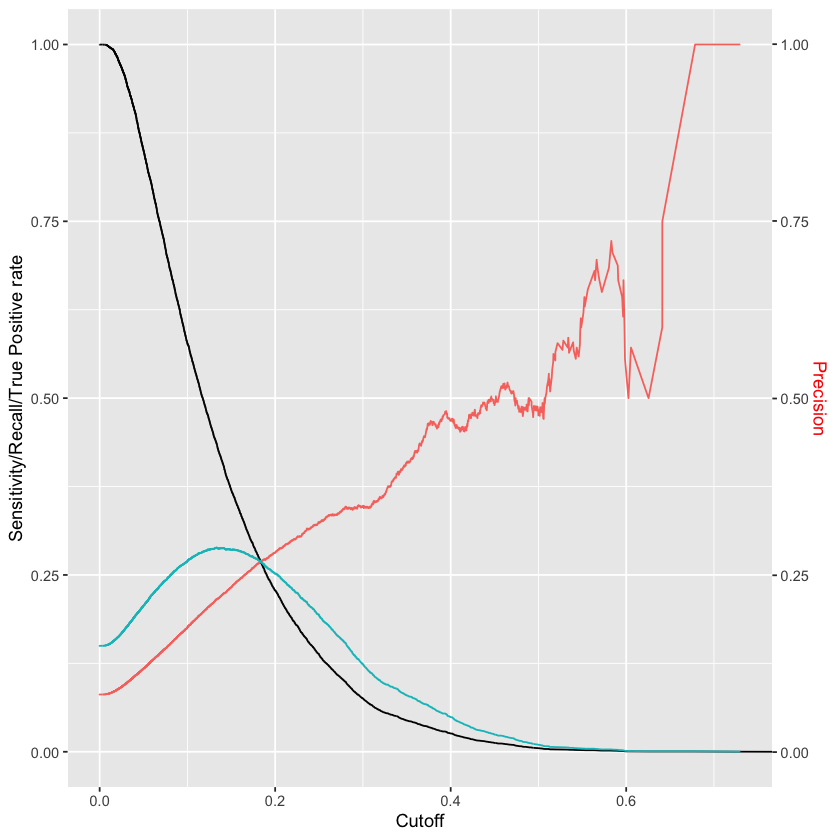

Confusion Matrix and Statistics

          actual
pred_class     0     1
         0 19139  1104
         1  3272   856
                                          
               Accuracy : 0.8204          
                 95% CI : (0.8156, 0.8252)
    No Information Rate : 0.9196          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.1932          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.43673         
            Specificity : 0.85400         
         Pos Pred Value : 0.20736         
         Neg Pred Value : 0.94546         
             Prevalence : 0.08042         
         Detection Rate : 0.03512         
   Detection Prevalence : 0.16938         
      Balanced Accuracy : 0.64537         
                                          
       'Positive' Class : 1               
                     

[1] "The test sample F1-Score for the OLS Logistic Regression is: 0.281."
[1] "The test sample Accuracy Ratio for the OLS Logistic Regression is: 0.475."


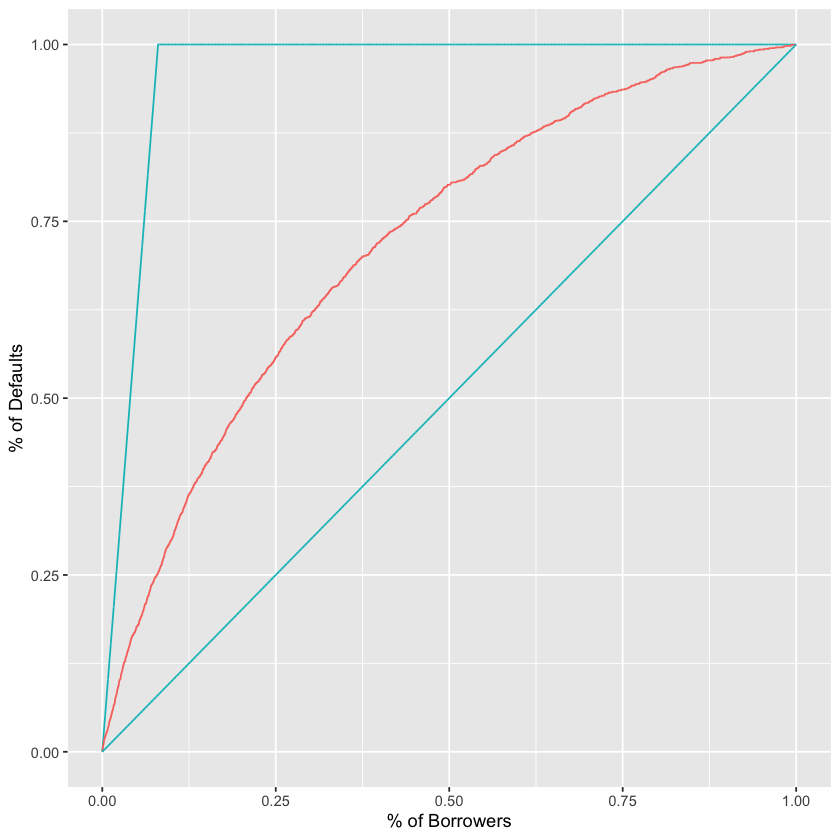

In [118]:
# print cv scores
coefs = summary(logit)$coef[which(summary(logit)$coef[,4]<.05), ]
coefs = data.frame( estimates = round(coefs[,1],3) , significance = round(coefs[,4],3) , absEst=abs(coefs[,1])) %>% arrange(desc(absEst))
coefs %>% head(10)

logit_test = test %>% 
    mutate(Client_Income = (Client_Income - mean(test$Client_Income)) / sd(test$Client_Income)
           , Credit_Amount = (Credit_Amount - mean(test$Credit_Amount)) / sd(test$Credit_Amount)
           , Employed_Days = (Employed_Days - mean(test$Employed_Days)) / sd(test$Employed_Days)
           , Loan_Annuity = (Loan_Annuity - mean(test$Loan_Annuity)) / sd(test$Loan_Annuity))


pred <- predict(logit, newdata = logit_train, type="prob")
actual = training$Default
predictions <- prediction(as.numeric(pred[,2]),as.numeric(actual))  
levels(actual) = c(0,1)

sens <- data.frame(x=unlist(performance(predictions, "sens")@x.values), 
                   y=unlist(performance(predictions, "sens")@y.values))
spec <- data.frame(x=unlist(performance(predictions, "spec")@x.values), 
                   y=unlist(performance(predictions, "spec")@y.values))
tpr <- data.frame(x=unlist(performance(predictions, "tpr")@x.values), 
                   y=unlist(performance(predictions, "tpr")@y.values))
prec <- data.frame(x=unlist(performance(predictions, "ppv")@x.values), 
                   y=unlist(performance(predictions, "ppv")@y.values))
f1 = data.frame(x = unlist(performance(predictions, "f", alpha = .5)@x.values), 
                y = unlist(performance(predictions, "f", alpha = .5)@y.values))

sens %>% ggplot(aes(x,y)) + 
  geom_line() + 
  geom_line(data=prec, aes(x,y,col="red")) +
  geom_line(data=f1, aes(x,y, col="steelblue")) +
  scale_y_continuous(sec.axis = sec_axis(~., name = "Precision")) +
  labs(x='Cutoff', y="Sensitivity/Recall/True Positive rate") +
  theme(axis.title.y.right = element_text(colour = "red"), legend.position="none") 


# now we report results
pred <- predict(logit, newdata = logit_test, type="prob")
actual = test$Default
levels(actual) = c(0,1)

# Cumulative Accuracy Profile 

# First, a perfect model
perfect =  as.numeric(actual)
perfect = sort(perfect, decreasing=TRUE)

# next, a 50/50 random model 
random = sum(perfect) / length(actual)
random = rep_len(random, length(perfect) ) # same length as orig vector

# last, our model
model = data.frame(pred = pred[,2], actual = as.numeric(actual) ) %>% arrange(desc(pred)) %>% dplyr::select(actual) %>% as.matrix()

# dataframe for plot
output = data.frame(Perfect = cumsum(perfect) / sum(perfect)
                    , Random = cumsum(random)/ sum(random) 
                    , Model = cumsum(model) / sum(model))

output %>% 
    ggplot(aes(Random, Perfect, col="steelblue", label="Perfect")) + 
    geom_line() + 
    geom_line(aes(Random, Model, col="red")) + 
    geom_line(aes(Random, Random, col="steelblue")) +
    labs(x='% of Borrowers', y = '% of Defaults') +
    theme(legend.position="none")
  

# accuracy ratio 
# Sort data in descending order of predicted prob.
preds = data.frame(pred = pred[,2] , y = as.numeric(actual))
preds = preds %>% arrange(desc(pred))

# Cumulative % borrowers
random = output$Random

# Cumulative % of defaults
cumlpercentbad = cumsum(preds$y)/sum(preds$y)

# Calculate AR
random = c(0, random)
cumlpercentbad = c(0, cumlpercentbad)
idx = 2:length(cumlpercentbad)

# trapezoidal rule to compute area under curve
AR_df=data.frame(cumlpercentpop = (random[idx] - random[idx-1]), 
                  cumlpercentbad = (cumlpercentbad[idx] + cumlpercentbad[idx-1]))
area = sum(AR_df$cumlpercentbad * AR_df$cumlpercentpop/2)
AR = (area - 0.5) /(0.5*(1-mean(preds$y)))



pred_class = ifelse(pred[,2] >=.13, 1, 0)
levels(pred_class) = c(0,1)
levels(actual) = c(0,1)
caret::confusionMatrix(table(pred_class,actual), positive = "1")

sens = caret::confusionMatrix(table(pred_class,actual), positive = "1")$byClass[1]
prec = caret::confusionMatrix(table(pred_class,actual), positive = "1")$byClass[3]
f1 = 2 * prec * sens / (sens + prec)


print(paste0("The test sample F1-Score for the Logistic Regression is: ", round(f1,3), "."))
print(paste0("The test sample Accuracy Ratio for the Logistic Regression is: ", round(AR,3), "."))

In [67]:
#SVM model - set probability = TRUE to get probabilities of 0 (not a default) and 1 (a default)
# fit = svm(factor(Default) ~ ., data = training_10pct, scale = TRUE, kernel = "radial", cost = 5, probability = TRUE)

#The following code captures accuracy of the SVM according to different costs.
#It may take a while to run...and may not be worthwhile

# costs = c(0.1, 1, 10, 100, 1000, 10000)
# acc <- c()
# for (i in costs){
# fit = svm(factor(Default) ~ ., data = training_10pct, scale = TRUE, kernel = "radial", cost = i, probability = TRUE)
# pred <- predict(fit, training_10pct)
# acc <- c(acc, mean(pred==training_10pct$Default))
# }
# acc

#Output of acc
#[1] 0.9202913 0.9202913 0.9338326 0.9854329 1.0000000 1.0000000
#Thus, even large changes of cost seem a bit inconsequential


# in creating the folds we specify the target feature (dependent variable) and # of folds
folds = createFolds(training_10pct$Default, k = 5)

# in cv we are going to applying a created function to our 'folds'
cv = lapply(folds, function(x) { 
    
  # in the next two lines we will separate the Training set into it's 5 pieces
  training_fold = training_10pct[-x, ] # training fold =  training set minus (-) it's sub test fold
  test_fold = training_10pct[x, ] # here we create the test fold 
    
  # now apply (train) the classifer on the training_fold
  classifier = svm(formula = factor(Default, levels=c(1,0)) ~ .,
                   data = training_fold,
                   type = 'C-classification',
                   kernel = 'radial', 
                   scale = TRUE, 
                   probability = TRUE, 
                   class.weights="inverse")
    
  # next step in the loop, we calculate the predictions and cm and we equate the accuracy
  # note we are training on training_fold and testing its accuracy on the test_fold
  y_pred = predict(classifier, newdata = test_fold %>% dplyr::select(-Default), probability=TRUE)
  probs = attr(y_pred, "probabilities")

  return(probs)
})

# final fit 
svm = svm(factor(Default) ~ ., data = training_10pct, scale = TRUE, kernel = "radial", cost = 5, probability = TRUE)


Warning message in svm.default(x, y, scale = scale, ..., na.action = na.action):
“Variable(s) ‘Mobile_Tag’ constant. Cannot scale data.”


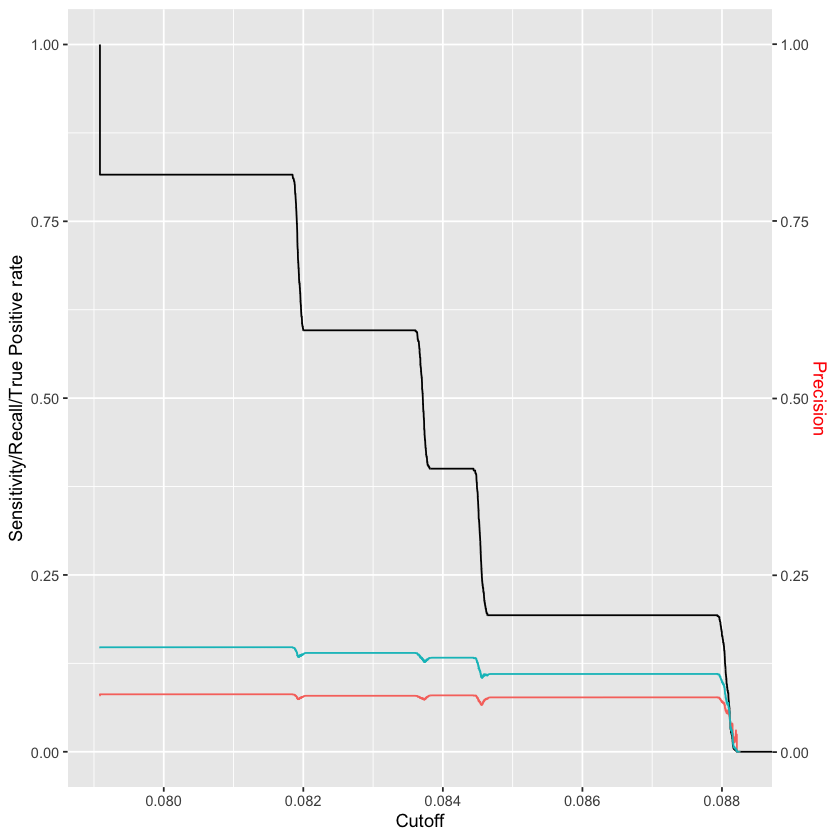

Confusion Matrix and Statistics

          actual
pred_class     0     1
         0 13274   882
         1  9137  1078
                                          
               Accuracy : 0.5889          
                 95% CI : (0.5827, 0.5951)
    No Information Rate : 0.9196          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.0487          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.55000         
            Specificity : 0.59230         
         Pos Pred Value : 0.10553         
         Neg Pred Value : 0.93769         
             Prevalence : 0.08042         
         Detection Rate : 0.04423         
   Detection Prevalence : 0.41915         
      Balanced Accuracy : 0.57115         
                                          
       'Positive' Class : 1               
                     

[1] "The test sample F1-Score for the Support Vector Machine is: 0.177."
[1] "The test sample Accuracy Ratio for the Support Vector Machine is: 0.179."


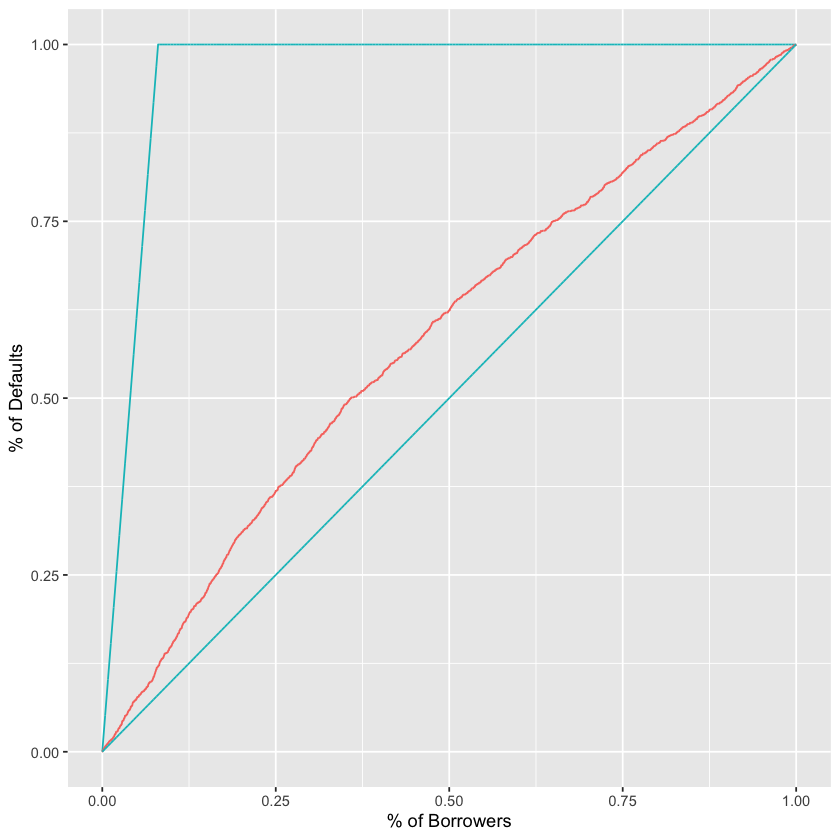

In [154]:
# pred <- predict(svm, newdata = training_10pct, type="prob")
# pred %>% head()

cv_pred = c(unname(unlist(cv$Fold1[,2]))
                , unname(unlist(cv$Fold2[,2]))
                , unname(unlist(cv$Fold3[,2]))
                , unname(unlist(cv$Fold4[,2]))
                , unname(unlist(cv$Fold5[,2])))

cv_actual = c(unname(unlist(training_10pct[folds$Fold1,39]))
                  , unname(unlist(training_10pct[folds$Fold2,39]))
                  , unname(unlist(training_10pct[folds$Fold3,39]))
                  , unname(unlist(training_10pct[folds$Fold4,39]))
                  , unname(unlist(training_10pct[folds$Fold5,39])))


predictions <- prediction(cv_pred, cv_actual)  

sens <- data.frame(x=unlist(performance(predictions, "sens")@x.values), 
                   y=unlist(performance(predictions, "sens")@y.values))
spec <- data.frame(x=unlist(performance(predictions, "spec")@x.values), 
                   y=unlist(performance(predictions, "spec")@y.values))
tpr <- data.frame(x=unlist(performance(predictions, "tpr")@x.values), 
                   y=unlist(performance(predictions, "tpr")@y.values))
prec <- data.frame(x=unlist(performance(predictions, "ppv")@x.values), 
                   y=unlist(performance(predictions, "ppv")@y.values))
f1 = data.frame(x = unlist(performance(predictions, "f", alpha = .5)@x.values), 
                y = unlist(performance(predictions, "f", alpha = .5)@y.values))

# pick the best cutoff based on f1-score
sens %>% ggplot(aes(x,y)) + 
  geom_line() + 
  geom_line(data=prec, aes(x,y,col="red")) +
  geom_line(data=f1, aes(x,y, col="steelblue")) +
  scale_y_continuous(sec.axis = sec_axis(~., name = "Precision")) +
  labs(x='Cutoff', y="Sensitivity/Recall/True Positive rate") +
  theme(axis.title.y.right = element_text(colour = "red"), legend.position="none") 

# Select 0.0805 as cutoff


svm_test = rbind(training_10pct[1,],test_test)
svm_test = svm_test[-1,] %>% mutate_all(~replace(., is.na(.), 0)) 

#The command to get the probabilities AND the default decision for each observation
pred <- predict(svm, newdata=svm_test, probability=TRUE)
probs <- attr(pred, "probabilities")
actual = svm_test$Default


# Cumulative Accuracy Profile 
# First, a perfect model
perfect =  as.numeric(actual)
perfect = sort(perfect, decreasing=TRUE)

# next, a 50/50 random model 
random = sum(perfect) / length(perfect)
random = rep_len(random, length(perfect) ) # same length as orig vector

# last, our model
model = data.frame(pred = probs[,2], actual = actual ) %>% arrange(desc(pred)) %>% dplyr::select(actual) %>% as.matrix()

# dataframe for plot
output = data.frame(Perfect = cumsum(perfect) / sum(perfect)
                    , Random = cumsum(random)/ sum(random) 
                    , Model = cumsum(model) / sum(model))

output %>% 
    ggplot(aes(Random, Perfect, col="steelblue", label="Perfect")) + 
    geom_line() + 
    geom_line(aes(Random, Model, col="red")) + 
    geom_line(aes(Random, Random, col="steelblue")) +
    labs(x='% of Borrowers', y = '% of Defaults') +
    theme(legend.position="none")
  

# accuracy ratio 
# Sort data in descending order of predicted prob.
preds = data.frame(pred = probs[,2] , y = actual)
preds = preds %>% arrange(desc(pred))

# Cumulative % borrowers
random = output$Random

# Cumulative % of defaults
cumlpercentbad = cumsum(preds$y)/sum(preds$y)

# Calculate AR
random = c(0, random)
cumlpercentbad = c(0, cumlpercentbad)
idx = 2:length(cumlpercentbad)

# trapezoidal rule to compute area under curve
AR_df=data.frame(cumlpercentpop = (random[idx] - random[idx-1]), 
                  cumlpercentbad = (cumlpercentbad[idx] + cumlpercentbad[idx-1]))
area = sum(AR_df$cumlpercentbad * AR_df$cumlpercentpop/2)
AR = (area - 0.5) /(0.5*(1-mean(preds$y)))

pred_class = ifelse(probs[,2] >=.0805, 1, 0)
levels(pred_class) = c(0,1)
levels(actual) = c(0,1)
caret::confusionMatrix(table(pred_class,actual), positive = "1")

sens = caret::confusionMatrix(table(pred_class,actual), positive = "1")$byClass[1]
prec = caret::confusionMatrix(table(pred_class,actual), positive = "1")$byClass[3]
f1 = 2 * prec * sens / (sens + prec)

print(paste0("The test sample F1-Score for the Support Vector Machine is: ", round(f1,3), "."))
print(paste0("The test sample Accuracy Ratio for the Support Vector Machine is: ", round(AR,3), "."))

options(warn = defaultW) # using to clean up output

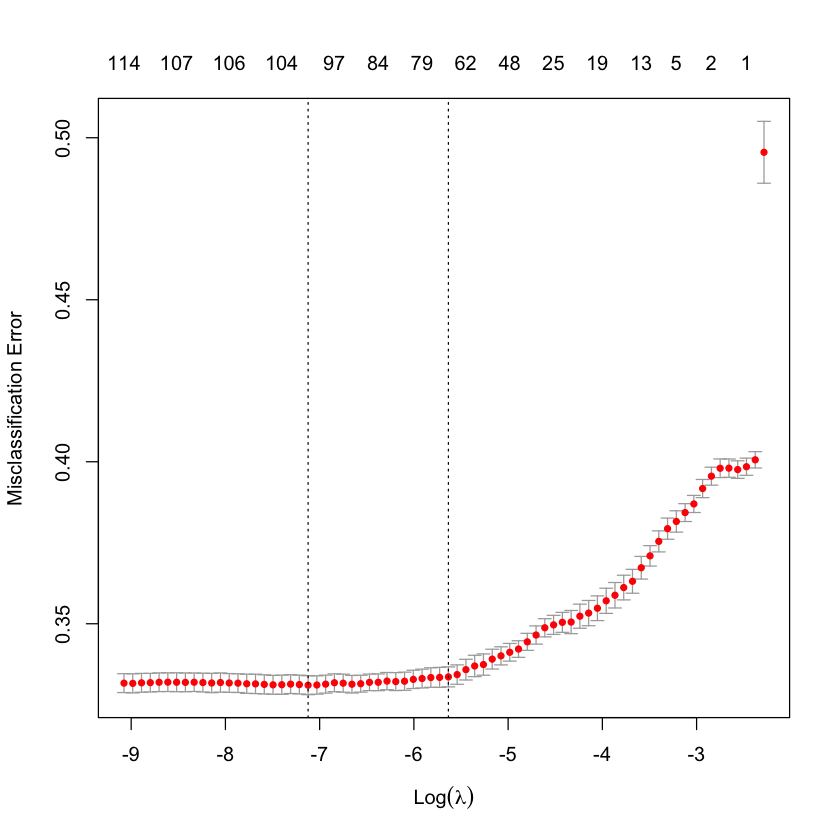

In [20]:
# Elastic Net

training_enet = model.matrix(Default ~ . , data = training)

weights = 1 / (table(actual)[actual] / length(actual))

cvfit = cv.glmnet(training_enet,training$Default, family = "binomial", type.measure = "class" , weights=weights, keep = TRUE)
plot(cvfit)

,estimates,absEst
,<dbl>,<dbl>
Score_Source_3,-2.621,2.621
(Intercept),1.834,1.834
Score_Source_3_na,-1.215,1.215
Score_Source_1,-1.047,1.047
Application_Process_Hour1,-1.036,1.036
Client_EducationPost Grad,-0.713,0.713
Score_Source_2,-0.698,0.698
Client_Income_TypeUnemployed,0.546,0.546
Social_Circle_Default,-0.532,0.532


Warning message:
“Removed 1 row(s) containing missing values (geom_path).”
Warning message:
“Removed 1 row(s) containing missing values (geom_path).”


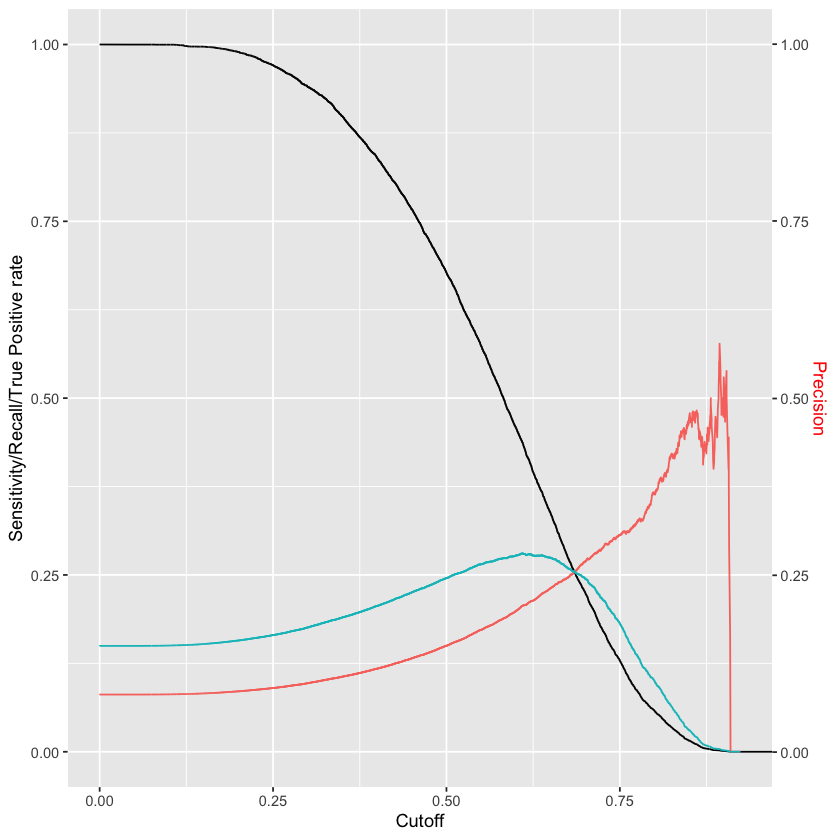

Confusion Matrix and Statistics

          actual
pred_class     0     1
         0 19416  1175
         1  2995   785
                                          
               Accuracy : 0.8289          
                 95% CI : (0.8241, 0.8336)
    No Information Rate : 0.9196          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.1875          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.40051         
            Specificity : 0.86636         
         Pos Pred Value : 0.20767         
         Neg Pred Value : 0.94294         
             Prevalence : 0.08042         
         Detection Rate : 0.03221         
   Detection Prevalence : 0.15510         
      Balanced Accuracy : 0.63344         
                                          
       'Positive' Class : 1               
                     

[1] "The test sample F1-Score for the Elastic Net Logistic Regression is: 0.274."
[1] "The test sample Accuracy Ratio for the Elastic Net Logistic Regression is: 0.462."


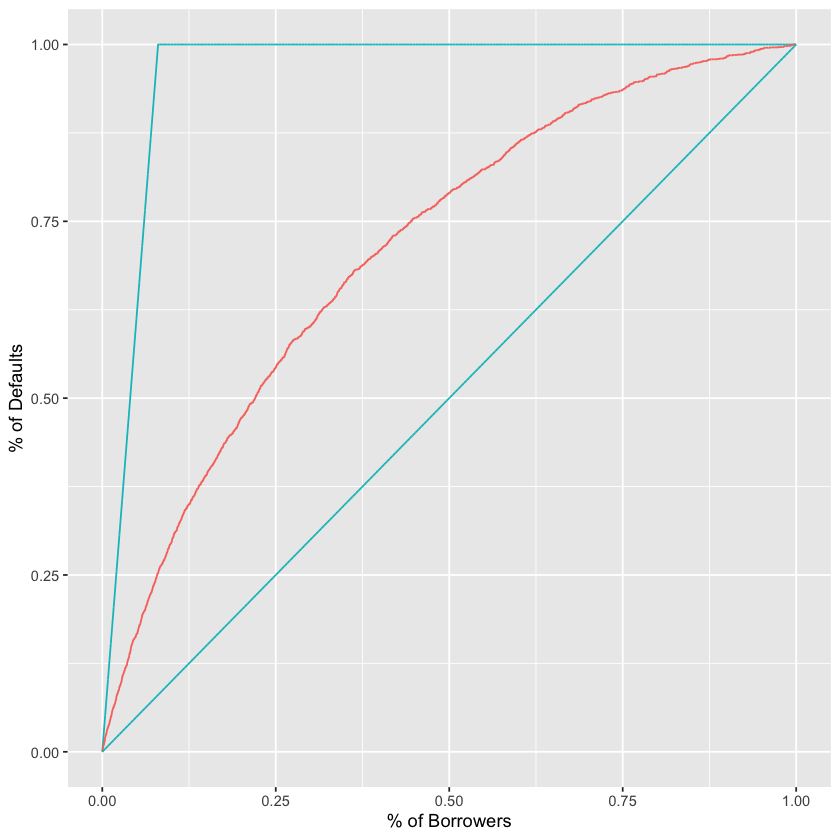

In [94]:
# cvfit$lambda.1se
# cvfit$lambda.min

# print cv scores
coefs = coef(cvfit)[which(abs(coef(cvfit)) > 0), ]
coefs = data.frame( estimates = round(coefs,3) , absEst=abs(round(coefs,3)) ) %>% arrange(desc(absEst))
coefs %>% head(10)

pred = predict(cvfit, newx = training_enet, type = "response", s = c(cvfit$lambda.1se, cvfit$lambda.min))
actual = training$Default
predictions <- prediction(pred[,1], actual) 

sens <- data.frame(x=unlist(performance(predictions, "sens")@x.values), 
                   y=unlist(performance(predictions, "sens")@y.values))
spec <- data.frame(x=unlist(performance(predictions, "spec")@x.values), 
                   y=unlist(performance(predictions, "spec")@y.values))
tpr <- data.frame(x=unlist(performance(predictions, "tpr")@x.values), 
                   y=unlist(performance(predictions, "tpr")@y.values))
prec <- data.frame(x=unlist(performance(predictions, "ppv")@x.values), 
                   y=unlist(performance(predictions, "ppv")@y.values))

f1 = data.frame(x = unlist(performance(predictions, "f", alpha = .5)@x.values), 
                y = unlist(performance(predictions, "f", alpha = .5)@y.values))

# pick cutoff based on F1-score
sens %>% ggplot(aes(x,y)) + 
  geom_line() + 
  geom_line(data=prec, aes(x,y,col="red")) +
  geom_line(data=f1, aes(x,y, col="steelblue")) +
  scale_y_continuous(sec.axis = sec_axis(~., name = "Precision")) +
  labs(x='Cutoff', y="Sensitivity/Recall/True Positive rate") +
  theme(axis.title.y.right = element_text(colour = "red"), legend.position="none") 

#Best cutoff is .62 to maximize F1 score on validation folds

# now we report results
test_enet = model.matrix(Default ~ . , data = test)
pred <- predict(cvfit, newx = test_enet, type="response", s = cvfit$lambda.1se)
actual = test$Default


# Cumulative Accuracy Profile 
# First, a perfect model
perfect =  as.numeric(actual)
perfect = sort(perfect, decreasing=TRUE)

# next, a 50/50 random model 
random = sum(perfect) / length(actual)
random = rep_len(random, length(perfect) ) # same length as orig vector

# last, our model
model = data.frame(pred = pred[,1], actual = as.numeric(actual)) %>% arrange(desc(pred)) %>% dplyr::select(actual) %>% as.matrix()

# dataframe for plot
output = data.frame(Perfect = cumsum(perfect) / sum(perfect)
                    , Random = cumsum(random)/ sum(random) 
                    , Model = cumsum(model) / sum(model))

output %>% 
    ggplot(aes(Random, Perfect, col="steelblue", label="Perfect")) + 
    geom_line() + 
    geom_line(aes(Random, Model, col="red")) + 
    geom_line(aes(Random, Random, col="steelblue")) +
    labs(x='% of Borrowers', y = '% of Defaults') +
    theme(legend.position="none")
  

# accuracy ratio 
# Sort data in descending order of predicted prob.
preds = data.frame(pred = pred[,1] , y = as.numeric(actual))
preds = preds %>% arrange(desc(pred))

# Cumulative % borrowers
random = output$Random

# Cumulative % of defaults
cumlpercentbad = cumsum(preds$y)/sum(preds$y)

# Calculate AR
random = c(0, random)
cumlpercentbad = c(0, cumlpercentbad)
idx = 2:length(cumlpercentbad)

# trapezoidal rule to compute area under curve
AR_df=data.frame(cumlpercentpop = (random[idx] - random[idx-1]), 
                  cumlpercentbad = (cumlpercentbad[idx] + cumlpercentbad[idx-1]))
area = sum(AR_df$cumlpercentbad * AR_df$cumlpercentpop/2)
AR = (area - 0.5) /(0.5*(1-mean(preds$y)))

pred_class = ifelse(pred[,1] >=.62, 1, 0)
levels(pred_class) = c(0,1)
levels(actual) = c(0,1)
caret::confusionMatrix(table(pred_class,actual), positive = "1")

sens = caret::confusionMatrix(table(pred_class,actual), positive = "1")$byClass[1]
prec = caret::confusionMatrix(table(pred_class,actual), positive = "1")$byClass[3]
f1 = 2 * prec * sens / (sens + prec)

print(paste0("The test sample F1-Score for the Elastic Net Logistic Regression is: ", round(f1,3), "."))
print(paste0("The test sample Accuracy Ratio for the Elastic Net Logistic Regression is: ", round(AR,3), "."))


In [134]:

## TRAIN RANDOM FOREST
control = trainControl(method="cv", number=5, search="random", classProbs=TRUE, savePredictions="final", summaryFunction = prSummary)

rf_training_10pct = training_10pct %>% mutate(Default = case_when(Default==1~"Yes", TRUE~"No") %>% as.factor())
levels(rf_training_10pct$Default) = c("No","Yes")

#create tunegrid
tunegrid <- expand.grid(.mtry = c(sqrt(ncol(rf_training_10pct))))
modellist <- list()

# #train with different ntree parameters
# for (ntree in c(1000,1500,2000,2500)){
#   rf <- train(Default~.,
#                data = rf_training_10pct,
#                method = 'rf',
#                metric = 'F',
#                tuneGrid = tunegrid,
#                trControl = control,
#                ntree = ntree)
#   key <- toString(ntree)
#   modellist[[key]] <- rf
# }

# best is with 1500 trees 

#train with different ntree parameters
for (ntree in c(100, 1500)){  # need two to 
  rf <- train(Default~.,
               data = rf_training_10pct,
               method = 'rf',
               metric = 'F',
               tuneGrid = tunegrid,
               trControl = control,
               ntree = ntree)
  key <- toString(ntree)
  modellist[[key]] <- rf
}

#Compare results
results <- resamples(modellist)
summary(results)



Call:
summary.resamples(object = results)

Models: 100, 1500 
Number of resamples: 5 

AUC 
          Min.   1st Qu.    Median      Mean   3rd Qu.      Max. NA's
100  0.9386503 0.9388597 0.9412902 0.9423513 0.9461614 0.9467950    0
1500 0.9515352 0.9548994 0.9577413 0.9567443 0.9595889 0.9599569    0

F 
          Min.   1st Qu.    Median      Mean   3rd Qu.      Max. NA's
100  0.9583333 0.9585894 0.9586115 0.9587476 0.9588455 0.9593583    0
1500 0.9585894 0.9585894 0.9586115 0.9587475 0.9588455 0.9591018    0

Precision 
         Min.  1st Qu.    Median      Mean   3rd Qu.      Max. NA's
100  0.920000 0.920472 0.9205128 0.9207641 0.9209446 0.9218911    0
1500 0.920472 0.920472 0.9205128 0.9207638 0.9209446 0.9214176    0

Recall 
     Min. 1st Qu. Median Mean 3rd Qu. Max. NA's
100     1       1      1    1       1    1    0
1500    1       1      1    1       1    1    0


rf variable importance

  only 20 most important variables shown (out of 112)

                           Overall
Score_Source_2              100.00
Score_Source_3               88.75
Age_Days                     84.13
Registration_Days            84.03
ID_Days                      83.79
Loan_Annuity                 80.21
Employed_Days                79.42
Credit_Amount                78.32
Phone_Change                 77.49
Population_Region_Relative   70.74
Client_Income                66.16
Score_Source_1               47.34
Social_Circle_Default        46.07
Credit_Bureau                44.16
Client_Family_Members        32.50
Own_House_Age                31.95
Child_Count                  21.56
Cleint_City_Rating           21.26
Active_Loan                  17.10
Bike_Owned                   15.41

Confusion Matrix and Statistics

          actual
pred_class    0    1
         0  596    0
         1 8375  777
                                         
               Accuracy : 0.1408         
                 95% CI : (0.134, 0.1479)
    No Information Rate : 0.9203         
    P-Value [Acc > NIR] : 1              
                                         
                  Kappa : 0.0112         
                                         
 Mcnemar's Test P-Value : <2e-16         
                                         
            Sensitivity : 1.00000        
            Specificity : 0.06644        
         Pos Pred Value : 0.08490        
         Neg Pred Value : 1.00000        
             Prevalence : 0.07971        
         Detection Rate : 0.07971        
   Detection Prevalence : 0.93886        
      Balanced Accuracy : 0.53322        
                                         
       'Positive' Class : 1              
                                         

Warning message:
“Removed 1 row(s) containing missing values (geom_path).”
Warning message:
“Removed 1 row(s) containing missing values (geom_path).”


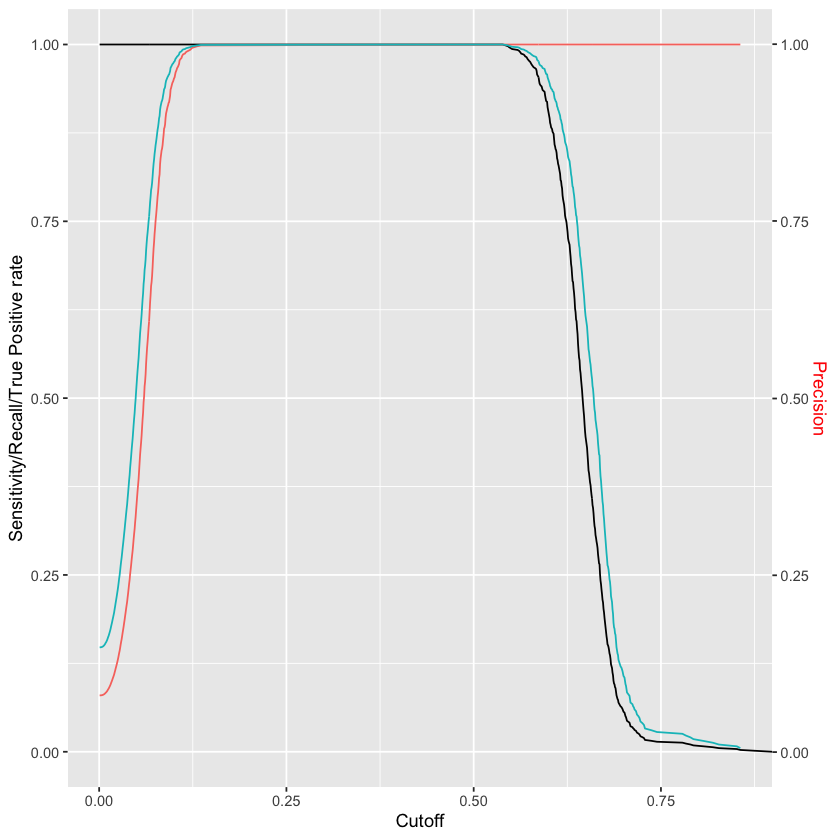

,No,Yes
,<dbl>,<dbl>
4,0.9133333,0.08666667
5,0.9506667,0.04933333
7,0.9620000,0.03800000
8,0.9726667,0.02733333
26,0.8946667,0.10533333


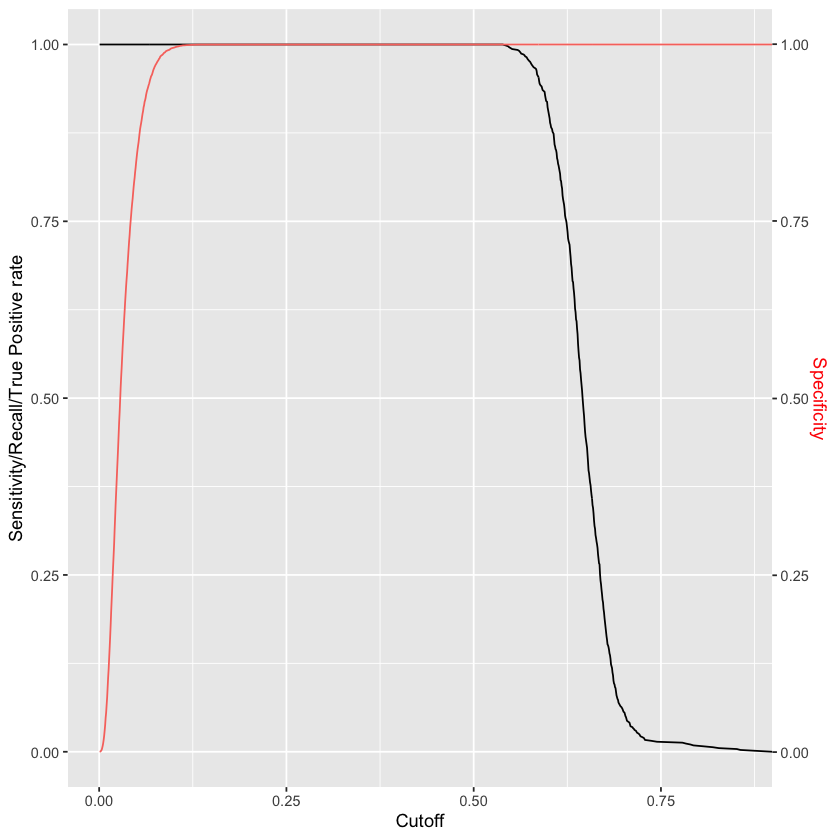

Confusion Matrix and Statistics

          actual
pred_class     0     1
         0 18990  1188
         1  3421   772
                                          
               Accuracy : 0.8109          
                 95% CI : (0.8059, 0.8158)
    No Information Rate : 0.9196          
    P-Value [Acc > NIR] : 1               
                                          
                  Kappa : 0.1587          
                                          
 Mcnemar's Test P-Value : <2e-16          
                                          
            Sensitivity : 0.39388         
            Specificity : 0.84735         
         Pos Pred Value : 0.18412         
         Neg Pred Value : 0.94112         
             Prevalence : 0.08042         
         Detection Rate : 0.03168         
   Detection Prevalence : 0.17205         
      Balanced Accuracy : 0.62061         
                                          
       'Positive' Class : 1               
                     

[1] "The test sample F1-Score for the Random Forest Classifier is: 0.251."
[1] "The test sample Accuracy Ratio for the Random Forest Classifier is: 0.41."


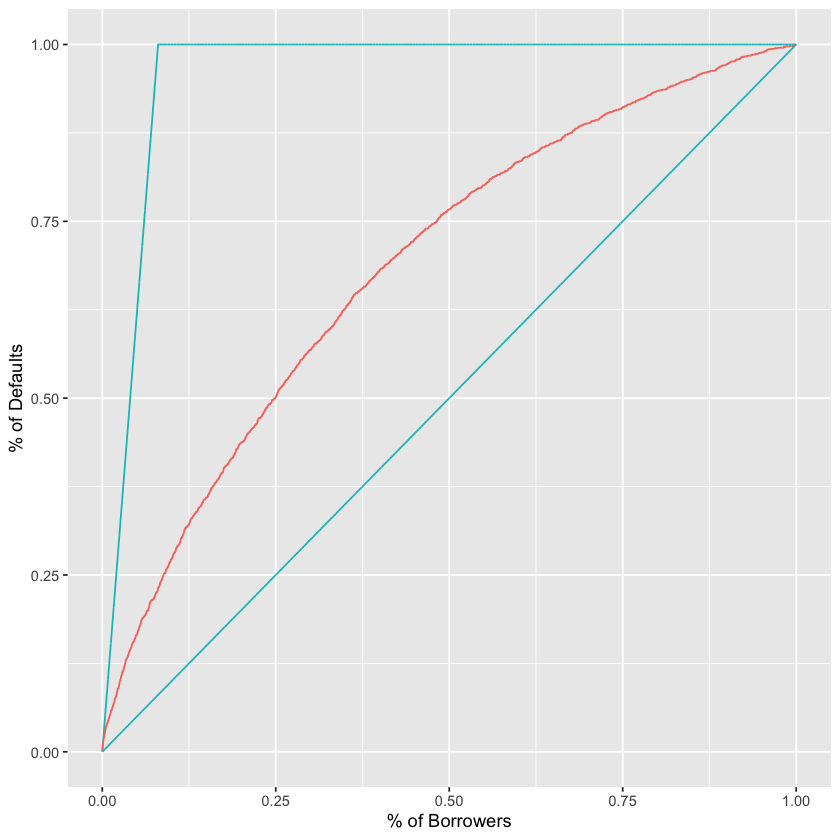

In [141]:

varImp(modellist$`1500`)
pred = predict(modellist$`1500`, rf_training_10pct, type="prob")
actual = case_when(rf_training_10pct$Default=="Yes" ~ 1, TRUE ~ 0)
# pred %>% head(5)

pred_class = ifelse(pred[,2] >=.01, 1, 0)
levels(pred_class) = c(1,0)
levels(actual) = c(1,0)
caret::confusionMatrix(table(pred_class,actual), positive = "1")

actual = case_when(rf_training_10pct$Default=="Yes" ~ 1, TRUE ~ 0)
predictions <- prediction(pred[,2], actual) 


sens <- data.frame(x=unlist(performance(predictions, "sens")@x.values), 
                   y=unlist(performance(predictions, "sens")@y.values))
spec <- data.frame(x=unlist(performance(predictions, "spec")@x.values), 
                   y=unlist(performance(predictions, "spec")@y.values))
tpr <- data.frame(x=unlist(performance(predictions, "tpr")@x.values), 
                   y=unlist(performance(predictions, "tpr")@y.values))
prec <- data.frame(x=unlist(performance(predictions, "ppv")@x.values), 
                   y=unlist(performance(predictions, "ppv")@y.values))

f1 = data.frame(x = unlist(performance(predictions, "f", alpha = .5)@x.values), 
                y = unlist(performance(predictions, "f", alpha = .5)@y.values))


# pick cutoff based on F1-score in training data
sens %>% ggplot(aes(x,y)) + 
  geom_line() + 
  geom_line(data=prec, aes(x,y,col="red")) +
  geom_line(data=f1, aes(x,y, col="steelblue")) +
  scale_y_continuous(sec.axis = sec_axis(~., name = "Precision")) +
  labs(x='Cutoff', y="Sensitivity/Recall/True Positive rate") +
  theme(axis.title.y.right = element_text(colour = "red"), legend.position="none") 

sens %>% ggplot(aes(x,y)) + 
  geom_line() + 
  geom_line(data=spec, aes(x,y,col="red")) +
  scale_y_continuous(sec.axis = sec_axis(~., name = "Specificity")) +
  labs(x='Cutoff', y="Sensitivity/Recall/True Positive rate") +
  theme(axis.title.y.right = element_text(colour = "red"), legend.position="none") 

# .125 is our chosen cutoff


# now we report results based on the test sample
rf_test = test_test %>% mutate(Default = factor(case_when(Default == 0 ~ "No", TRUE ~ "Yes"), levels = c("No", "Yes")))
pred = predict(modellist$`1500`, rf_test, type="prob")
actual = case_when(rf_test$Default=="Yes" ~ 1, TRUE ~ 0)


# Cumulative Accuracy Profile 
# First, a perfect model
perfect =  actual
perfect = sort(perfect, decreasing=TRUE)

# next, a 50/50 random model 
random = sum(perfect) / length(actual)
random = rep_len(random, length(perfect) ) # same length as orig vector

# last, our model
model = data.frame(pred = pred[,2], actual = as.numeric(actual)) %>% arrange(desc(pred)) %>% dplyr::select(actual) %>% as.matrix()

# dataframe for plot
output = data.frame(Perfect = cumsum(perfect) / sum(perfect)
                    , Random = cumsum(random)/ sum(random) 
                    , Model = cumsum(model) / sum(model))

output %>% 
    ggplot(aes(Random, Perfect, col="steelblue", label="Perfect")) + 
    geom_line() + 
    geom_line(aes(Random, Model, col="red")) + 
    geom_line(aes(Random, Random, col="steelblue")) +
    labs(x='% of Borrowers', y = '% of Defaults') +
    theme(legend.position="none")
  

# accuracy ratio 
# Sort data in descending order of predicted prob.
preds = data.frame(pred = pred[,2] , y = as.numeric(actual))
preds = preds %>% arrange(desc(pred))

# Cumulative % borrowers
random = output$Random

# Cumulative % of defaults
cumlpercentbad = cumsum(preds$y)/sum(preds$y)

# Calculate AR
random = c(0, random)
cumlpercentbad = c(0, cumlpercentbad)
idx = 2:length(cumlpercentbad)

# trapezoidal rule to compute area under curve
AR_df=data.frame(cumlpercentpop = (random[idx] - random[idx-1]), 
                  cumlpercentbad = (cumlpercentbad[idx] + cumlpercentbad[idx-1]))
area = sum(AR_df$cumlpercentbad * AR_df$cumlpercentpop/2)
AR = (area - 0.5) /(0.5*(1-mean(preds$y)))

pred_class = ifelse(pred[,2] >=.125, 1, 0)
levels(pred_class) = c(0,1)
levels(actual) = c(0,1)
caret::confusionMatrix(table(pred_class,actual), positive = "1")

sens = caret::confusionMatrix(table(pred_class,actual), positive = "1")$byClass[1]
prec = caret::confusionMatrix(table(pred_class,actual), positive = "1")$byClass[3]
f1 = 2 * prec * sens / (sens + prec)

print(paste0("The test sample F1-Score for the Random Forest Classifier is: ", round(f1,3), "."))
print(paste0("The test sample Accuracy Ratio for the Random Forest Classifier is: ", round(AR,3), "."))

